In [1]:
import numpy as np
from matplotlib import pyplot as plt

import torch

import cv2

import os
from Dataset.data import DataPath
from Dataset.DataSetLoaders.ChessDataset import ChessDataset, GameDataset

import importlib
import ChessLens
importlib.reload(ChessLens);

In [2]:
# ds = ChessDataset(
#     config={
#         "img_size": (640,640)
#     }
# )
ds = GameDataset(
    config={
        "img_size": (640,640)
    }
)
# img, y = ds[400]
# img, y = ds[278]
img, y = ds[57]

# img = ChessLens.ChessLensImage('/mnt/D/University/Thesis_Dataset/Temp/img_now_2.jpeg', "cnn")
# img = ChessLens.ChessLensImage("/mnt/D/University/Thesis_Dataset/Temp/photo_84.jpg", "cnn")
# img = ChessLens.ChessLensImage("/mnt/D/University/Thesis_Dataset/Temp/photo_80.jpg", "cnn")
img = ChessLens.ChessLensImage(img, "cnn")
y["image_path"]

'/mnt/D/University/Thesis_Dataset/Games/Training_Session/game_57.jpg'

In [3]:
quad, conf = img.detect_board()
# img.recognize_clock()
img.recognize_pieces()
img.save_fen_image()

In [4]:
img.board_detection[1]

tensor([497., 108.])

'RP4pr/1P4pn/BPN1p3/QP3p1q/1P3qpr/RPN2npb/KP4p1/1P4pr'

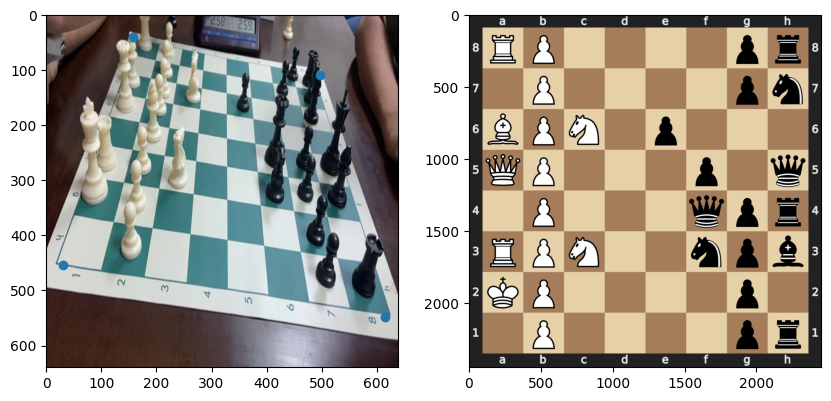

In [5]:
plt.figure(figsize=(10, 10))

plt.subplot(1,2,1)
plt.imshow(img.img.permute(1,2,0));
plt.scatter(img.board_detection[:,0], img.board_detection[:,1]);
plt.subplot(1,2,2)
plt.imshow(plt.imread("out_fen.png"));
img.fen

array([[     1.3713,     0.50563,     -281.11],
       [     -0.106,      2.3239,     -311.45],
       [ -0.0003681,   0.0046337,           1]])

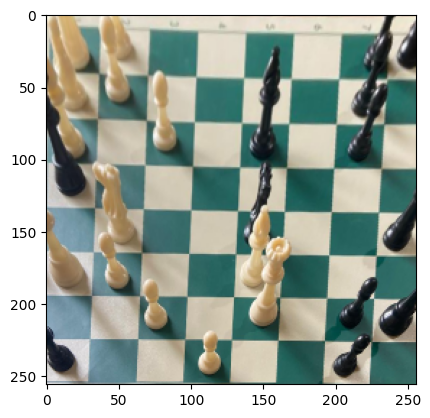

In [13]:
warpped_img, M = img.warp()
plt.imshow(warpped_img);
M